# Punto a)

## 1) Generación del dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 500 #Cantidad de muestras
X = np.random.uniform(low = -1, high = 1, size = N)

sigma = np.sqrt(0.04)

normal = np.random.normal(loc = 0, scale = sigma, size = N)

media = np.maximum(0, X)

Y = normal + media #Si X fue más que 0, lo sumo al valor de la normal


## 2) Grafico con scatter

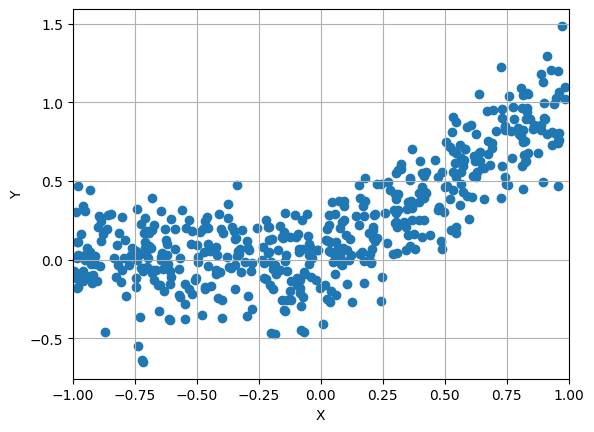

In [3]:
plt.scatter(X, Y)
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(-1, 1)
plt.grid(True)

# b) Cálculos teóricos.

## 1) Esperanzas y varianzas

Dado que $X \sim \mathcal{U}(-1, 1)$ tiene esperanza y varianza conocida

$\mathbb{E}[X] = \frac{1 + (-1)}{2} = 0$

$var[X] = \frac{(1 - (-1))^2}{12} = \frac{1}{3}$



La esperanza de $Y$ se calcula como la esperanza de la esperanza condicional

$\mathbb{E}[Y|X] = r(X)$

Luego $\mathbb{E}[Y] = \mathbb{E}[r(X)] = \int_{-\infty}^{\infty} r(x)\cdot f_X(x)\,dx = \int_0^1 \frac{x}{2} \, dx = \frac{1}{4}$



La varianza de $Y$ se puede calcular con la siguiente propiedad:

$var[Y] = \mathbb{E}[var[Y|X]]+ var[\mathbb{E}[Y|X]]$

Dado que $var[Y|X = x] = \sigma^2 = 0.04$ independientemente del valor de $x$, se tiene que

$\mathbb{E}[var[Y|X]] = 0.04$

Por otro lado, se tiene que $var[\mathbb{E}[Y|X]] = var[r(X)] = \mathbb{E}[r(X)^2] - \mathbb{E}[r(X)]^2 = \mathbb{E}[r(X)^2] - (\frac{1}{4})^2$

El término $\mathbb{E}[r(X)^2]$ se puede calcular como

$\mathbb{E}[r(X)^2] = \int_0^1 \frac{x^2}{2}dx = \frac{1}{6}$

Entonces $var[\mathbb{E}[Y|X]] = \frac{1}{6} - (\frac{1}{4})^2 = \frac{5}{48}$

y finalmente $var[Y] = 0.04 + \frac{5}{48} = \frac{173}{1200} \approx 0.144$

Por último, hay que calcular $\mathbb{E}[YX]$, para lo cual se puede usar la siguiente propiedad:

$
\mathbb{E}[Yg(X)] = \mathbb{E}[\mathbb{E}[Y|X]g(X)]
$
considerando $g(X) = X$

Entonces:

$
\mathbb{E}[YX] = \mathbb{E}[\mathbb{E}[Y|X]X] = \mathbb{E}[r(X)X] = \int_0^1\frac{x^2}{2}dx = \frac{1}{6}
$

## 2) Regresor óptimo y error bayesiano

El regresor óptimo es aquel que minimiza el error cuadrático mdeio (ECM):

$
ECM = \mathbb{E}[(Y - \varphi (X))^2]
$

Se sabe que el regresor óptimo es la esperanza condicional.

$
\varphi (x) = \mathbb{E}[Y|X=x] = r(x) = \mathbb{1} \{0<x\}
$

Luego $\varphi(X) = r(X)$ y el error bayesiano asociado es

$
\mathbb{E}[(Y - \varphi (X))^2] = \mathbb{E}[var[Y|X]] = \mathbb{E}[\sigma^2] = \sigma^2 = 0.04
$

## 3) Mejor predictor sin observar $X$

Se quiere hallar la constante $c$ tal que se minimiza el ECM al predecir X, es decir

$
c = \arg \min_{c} \mathbb{E}[(Y - c)^2]
$

Se sabe que tal constante es la esperanza de Y, $c = \mathbb{E}[Y] = \frac{1}{4}$

El error esperado es calcular $\mathbb{E}[(Y - \mathbb{E}[Y])^2]$, que es la varianza de $Y$

$
\mathbb{E}[(Y - \mathbb{E}[Y])^2] = var[Y] = \sigma^2 = 0.144
$

# c) Regresión lineal

## 1) Creación de la clase

In [4]:
class RegLineal:
  def __init__(self, X, y):
    self.params = np.array([0,0]) #parámetros de la regresión (orednada de origen y pendiente)
    self._X = np.zeros((len(X), 2)) #Matriz X, como en las filminas de la teórica. Vectorización del problema
    self._X[:, 0] = 1
    self._X[:, 1] = X
    self._Y = y
    self.pendientes = np.array([]) #en este vector voy a guardar los valores de la pendiente cuando use el gradiente descendente

  def fit(self):
    self.params = np.linalg.pinv(self._X) @ self._Y #Cálculo de los parámetros por la pseudoinversa

  def predic(self, x):
    return self.params[0] + self.params[1] * x

  def err_predict(self, X, y): #Dados los pares (X, Y) esta función predice los valores de y (y_predict) y calcula el desvío respecto de los y recibidos
    y_predict = self.predic(X)
    return np.mean((y - y_predict)**2)

  def fit_gradient(self, learning_rate, n_iter):
    self.params = np.array([0,0]) #Reescribo los parámetros
    self.pendientes = np.zeros((n_iter))
    for i in range(n_iter):
      grad = (2/len(self._X[:, 0])) * (self._X.T @ (self._X @ self.params) - self._X.T @ self._Y)
      self.params = self.params - learning_rate * grad
      self.pendientes[i] = self.params[1]


## 2) Entrenamiento con el data set

In [5]:
regresion = RegLineal(X, Y)
regresion.fit()

## 3) Cálculo del error de entrenamiento

In [6]:
error = regresion.err_predict(X, Y)
print(f"El error de entrenamiento fue de {error:.3f}")

El error de entrenamiento fue de 0.063


## 4) Predicción de $y$ para $x = 0.5$

In [7]:
x_predict = regresion.predic(0.5)
print(f"El valor de y predicho fue de y = {x_predict:.3f}")

El valor de y predicho fue de y = 0.485


## 5) Gráfico del estimador lineal, el óptimo y el scatter

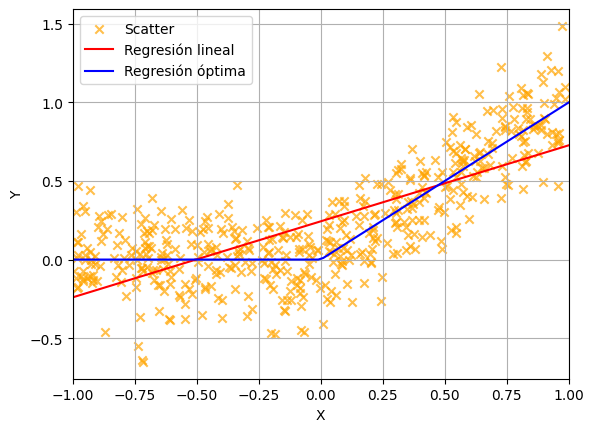

In [8]:
X_input = np.linspace(-1, 1, 100)
Y_reglin = regresion.predic(X_input)
Y_optimo = np.maximum(0, X_input)

plt.scatter(X, Y, label = 'Scatter', marker = 'x', color = 'orange', alpha = 0.70)
plt.plot(X_input, Y_reglin, label = 'Regresión lineal', color = 'r')
plt.plot(X_input, Y_optimo, label = 'Regresión óptima', color = 'b')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(-1, 1)
plt.legend()
plt.grid(True)

# d) Gradiente descendiente

## 1) Entrenamiento con el gradiente

In [9]:
n_iter = 1000
learning_rate = 0.01
regresion.fit_gradient(learning_rate, n_iter) #entreno con el gradiente

## 2) Error, predicción y gráficos superpuestos

In [10]:
error_grad = regresion.err_predict(X, Y)
print(f"El error de predicción usando el gradiente fue de {error_grad:.3f}")

y_predict_grad = regresion.predic(0.5)
print(f"Para x = 0.5 el modelo ahora predice y = {y_predict_grad:0.3f}")

El error de predicción usando el gradiente fue de 0.063
Para x = 0.5 el modelo ahora predice y = 0.485


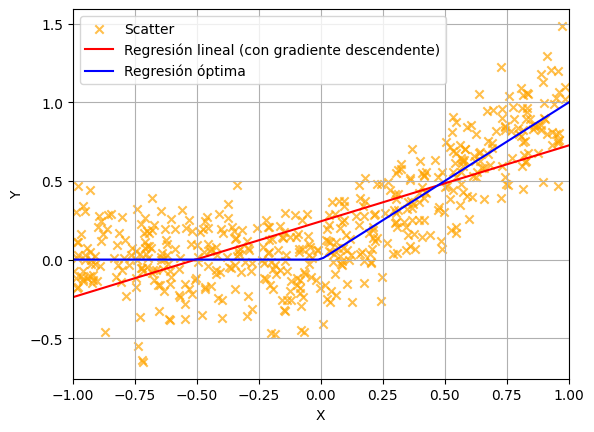

In [11]:
Y_grad = regresion.predic(X_input)

plt.scatter(X, Y, label = 'Scatter', marker = 'x', color = 'orange', alpha = 0.70)
plt.plot(X_input, Y_grad, label = 'Regresión lineal (con gradiente descendente)', color = 'r')
plt.plot(X_input, Y_optimo, label = 'Regresión óptima', color = 'b')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(-1, 1)
plt.legend()
plt.grid(True)

## 3) Gráfico de la evolución de la pendiente en función del número de iteraciones

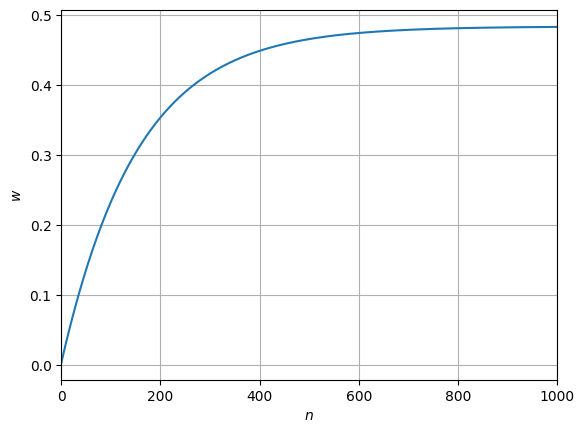

In [12]:
n = range(n_iter)
plt.plot(n, regresion.pendientes)
plt.xlabel(r'$n$')
plt.ylabel(r'$w$')

plt.xlim(0, n_iter)

plt.grid(True)

## Punto extra. ¿Qué pasa con distintos learning rates?

In [16]:
learning_rate = 0.001
regresion.fit_gradient(learning_rate, n_iter)

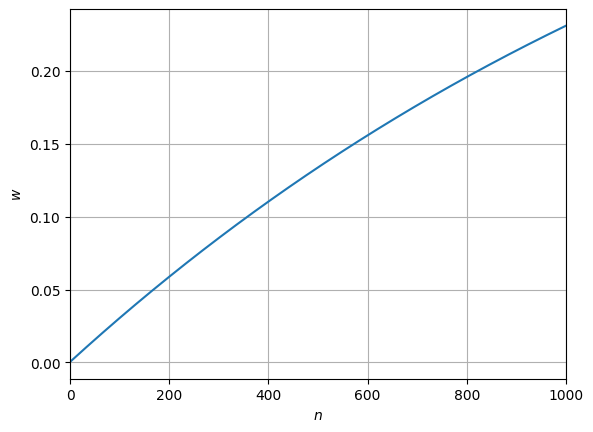

In [17]:
plt.plot(n, regresion.pendientes)
plt.xlabel(r'$n$')
plt.ylabel(r'$w$')

plt.xlim(0, n_iter)

plt.grid(True)

Obs: no llega a converger

In [26]:
learning_rate = 1

regresion.fit_gradient(learning_rate, n_iter)

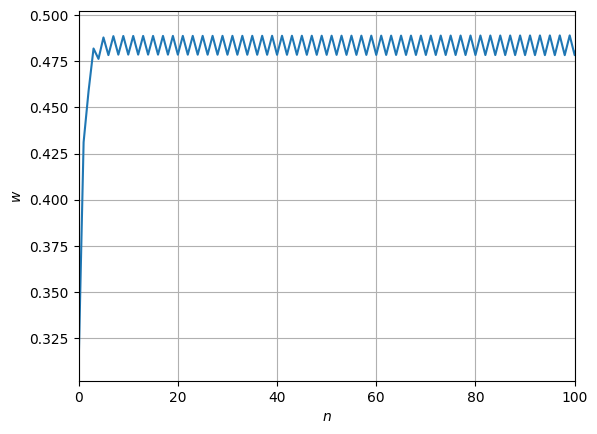

In [28]:
plt.plot(n, regresion.pendientes)
plt.xlabel(r'$n$')
plt.ylabel(r'$w$')

plt.xlim(0, 100)

plt.grid(True)

Obs: Converge bastante rápido y no hay ruido

# e) Regresión cuadrática

Ahora quiero aproximar $Y$ a partir de una observación de $X$ de la siguiente forma:

$
\hat{y} = c + bx+ax^2
$

La función de error (como función de $w = (c, b, a)$) es

$
J(w) = \frac{1}{n}∑_i^n(c + bx_i+ax_i^2 - y_i)^2
$

Como en el caso anterior, el problema se puede vectorizar de la siguiente forma:

Defino la matriz $\bar{X} =
\begin{bmatrix}
1 & x_1 & x_1^2 \\
1 & x_2 & x_2^2 \\
\vdots & \vdots & \vdots \\
1 & x_n & x_n^2
\end{bmatrix}
$ y el vector $w = (c, b, a)$. Entonces $J(w)$ queda:

$
J(w) = \frac{1}{n}∑_i^n||\bar{X}\cdot w - Y||^2
$

Como es exactamente la misma función de error que antes, el gradiente es el mismo, se anula en el mismo lugar y la hessiana sigue siendo definida positiva, por lo que el problema es convexo y la solución es la misma, solo que con una dimensión más.

In [13]:
class RegCuad:
  def __init__(self, X, y):
    self.w = np.array([0,0,0]) #parámetros de la regresión (orednada de origen y pendiente)
    self._X = np.zeros((len(X), 3)) #Matriz X, como en las filminas de la teórica. Vectorización del problema
    self._X[:, 0] = 1
    self._X[:, 1] = X
    self._X[:, 2] = X**2
    self._Y = y

  def fit(self):
    self.w = np.linalg.pinv(self._X) @ self._Y #Cálculo de los parámetros por la pseudoinversa

  def predic(self, x):
    return self.w[0] + self.w[1] * x + self.w[2] * x**2

  def err_predict(self, X, y): #Dados los pares (X, Y) esta función predice los valores de y (y_predict) y calcula el desvío respecto de los y recibidos
    y_predict = self.predic(X)
    return np.mean((y - y_predict)**2)
    #Tiene que hacer esto? Consultar?

In [14]:
cuad = RegCuad(X, Y)
cuad.fit()
print(cuad.w)
err_cuad = cuad.err_predict(X, Y)
print(f"El error de entrenamiento fue de {err_cuad:.3f}. Se acerca bastante al error bayesiano!!!")

[0.07450634 0.49936747 0.51433931]
El error de entrenamiento fue de 0.039. Se acerca bastante al error bayesiano!!!


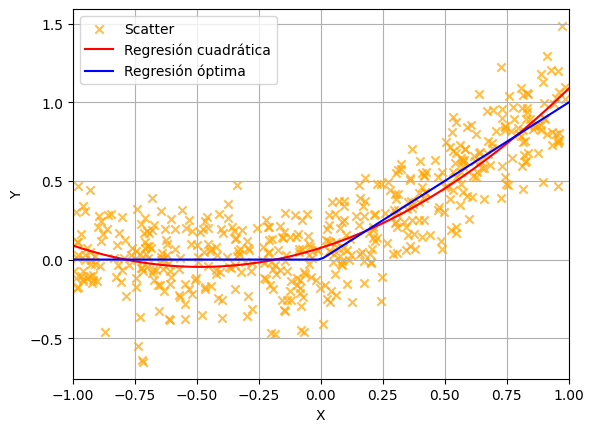

In [15]:
Y_cuad = cuad.predic(X_input)

plt.scatter(X, Y, label = 'Scatter', marker = 'x', color = 'orange', alpha = 0.70)
plt.plot(X_input, Y_cuad, label = 'Regresión cuadrática', color = 'r')
plt.plot(X_input, Y_optimo, label = 'Regresión óptima', color = 'b')
plt.xlabel('X')
plt.ylabel('Y')
plt.xlim(-1, 1)
plt.legend()
plt.grid(True)